In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")


## 1. Load the Dataset

The retail sales dataset is loaded using Pandas. The dataset contains transaction-level information that will be used to analyze sales performance, customer characteristics, and product trends.

In [2]:
df = pd.read_csv("retail_sales.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 2. Initial Dataset Inspection

Before performing the analysis, the dataset is inspected to understand its structure, dimensions, data types, missing values, and duplicate records. This helps identify potential data-quality issues before further analysis.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 9


In [4]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [6]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [7]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate records:",duplicate_count)

Number of duplicate records: 0


In [8]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,41.39,2.51,179.89,456.00
std,288.82,13.68,1.13,189.68,560.00
min,1.00,18.00,1.00,25.00,25.00
25%,250.75,29.00,1.00,30.00,60.00
50%,500.50,42.00,3.00,50.00,135.00
75%,750.25,53.00,4.00,300.00,900.00
max,1000.00,64.00,4.00,500.00,2000.00


In [9]:
df["Date"] = pd.to_datetime(df["Date"])

print("Date column data type:", df["Date"].dtype)

Date column data type: datetime64[us]


In [10]:
df["Month"] = df["Date"].dt.to_period("M")
df["Quarter"] = df["Date"].dt.to_period("Q")

df[["Date", "Month", "Quarter"]].head()

,Date,Month,Quarter
0,2023-11-24,2023-11,2023Q4
1,2023-02-27,2023-02,2023Q1
2,2023-01-13,2023-01,2023Q1
3,2023-05-21,2023-05,2023Q2
4,2023-05-06,2023-05,2023Q2


In [11]:
numeric_columns = df.select_dtypes(include="number").columns

statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
})

statistics

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.50,500.50,1.00,288.82
Age,41.39,42.00,43.00,13.68
Quantity,2.51,3.00,4.00,1.13
Price per Unit,179.89,50.00,50.00,189.68
Total Amount,456.00,135.00,50.00,560.00


## 5. Time Series Analysis

### 5.1 Monthly Sales Trend

Monthly sales are analyzed to identify changes in revenue over time. Aggregating total sales by month helps identify periods of stronger or weaker business performance.

In [12]:
monthly_sales = (
    df.groupby("Month")["Total Amount"]
    .sum()
    .reset_index()
)

monthly_sales["Month"] = monthly_sales["Month"].astype(str)

monthly_sales.head()

,Month,Total Amount
0,2023-01,35450
1,2023-02,44060
2,2023-03,28990
3,2023-04,33870
4,2023-05,53150


In [13]:
quarterly_sales = (
    df.groupby("Quarter")["Total Amount"]
    .sum()
    .reset_index()
)

quarterly_sales["Quarter"] = quarterly_sales["Quarter"].astype(str)

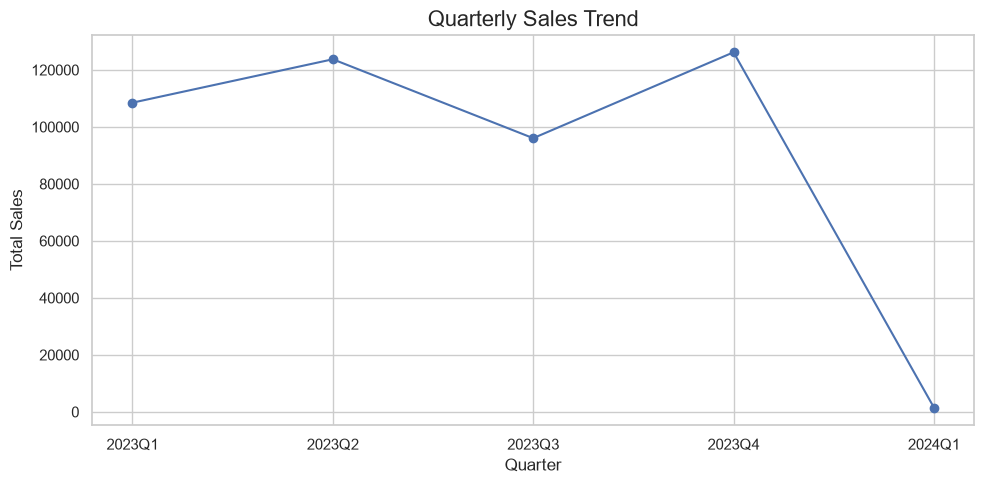

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    quarterly_sales["Quarter"],
    quarterly_sales["Total Amount"],
    marker="o"
)

plt.title("Quarterly Sales Trend", fontsize=16)
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Observation

Quarterly sales fluctuate considerably throughout the observed period. Sales increased from approximately 109,000 in Q1 2023 to around 124,000 in Q2 2023, before declining to approximately 96,000 in Q3. Sales then reached their highest level of about 126,000 in Q4 2023.

The sharp decline in Q1 2024 should be interpreted cautiously because the dataset appears to contain only a partial quarter for 2024. Therefore, the low Q1 2024 value does not necessarily indicate a significant deterioration in business performance. Overall, Q4 2023 recorded the strongest quarterly sales performance.

## 6. Customer Demographics

Understanding customer demographics helps identify the characteristics of the retail business's customer base. In this section, customer age groups and gender distribution are analyzed to identify the dominant demographic segments.x

In [15]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 25, 35, 45, 55, 65, 100],
    labels=[
        "Under 18",
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

age_group_counts = df["Age Group"].value_counts().sort_index()

age_group_counts

Age Group
Under 18     21
18-25       148
26-35       205
36-45       202
46-55       229
56-65       195
65+           0
Name: count, dtype: int64

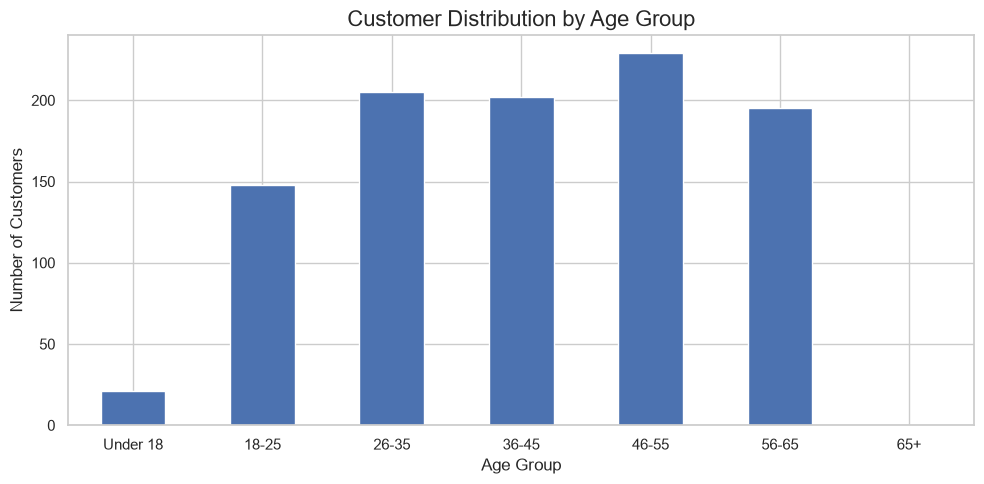

In [16]:
plt.figure(figsize=(10, 5))

age_group_counts.plot(kind="bar")

plt.title("Customer Distribution by Age Group", fontsize=16)
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 6.2 Gender Distribution

The gender distribution is analyzed to understand the composition of the customer base and determine whether the dataset has a relatively balanced or concentrated representation of male and female customers.

In [17]:
gender_counts = df["Gender"].value_counts()

gender_counts


Gender
Female    510
Male      490
Name: count, dtype: int64

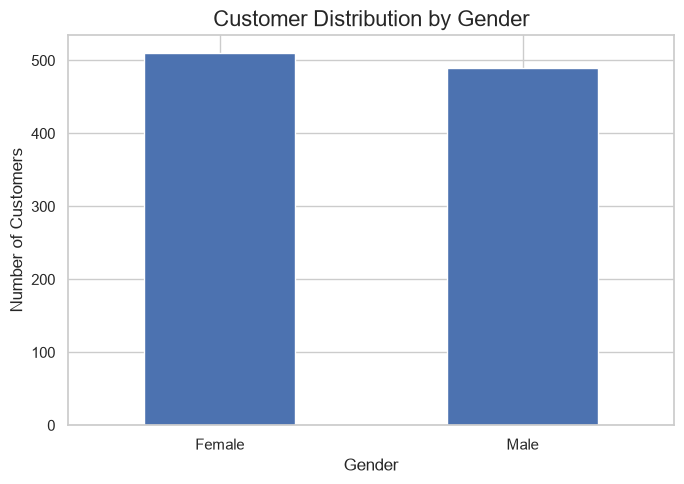

In [18]:
plt.figure(figsize=(7, 5))

gender_counts.plot(
    kind="bar"
)

plt.title("Customer Distribution by Gender", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The customer base is relatively balanced by gender, with female customers representing a slightly larger share than male customers. Approximately 51% of the records are female customers, while about 49% are male customers. This indicates that the retail business has a broadly diverse customer base rather than being strongly concentrated toward one gender.

## 7. Product Analysis

The dataset does not contain an individual product-name field. Therefore, individual top-10 product analysis cannot be performed directly. Instead, product categories are analyzed based on total quantity sold to identify the strongest-performing categories.

In [19]:
category_quantity = (
    df.groupby("Product Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

category_quantity

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

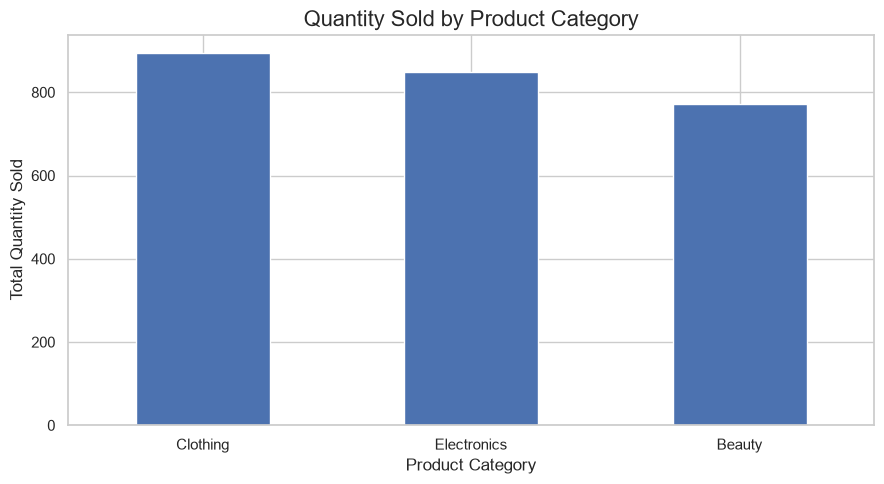

In [20]:
plt.figure(figsize=(9, 5))

category_quantity.plot(kind="bar")

plt.title("Quantity Sold by Product Category", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

Clothing has the highest total quantity sold, followed by Electronics, while Beauty has the lowest quantity sold among the three categories. This indicates that Clothing has the strongest sales volume in terms of units purchased. However, quantity sold alone does not determine revenue performance, so the revenue contribution of each category should also be considered.

### 7.2 Revenue by Product Category

Revenue performance is analyzed across product categories using the total transaction amount. This helps identify which categories contribute the most to overall sales revenue.

In [21]:
category_revenue = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

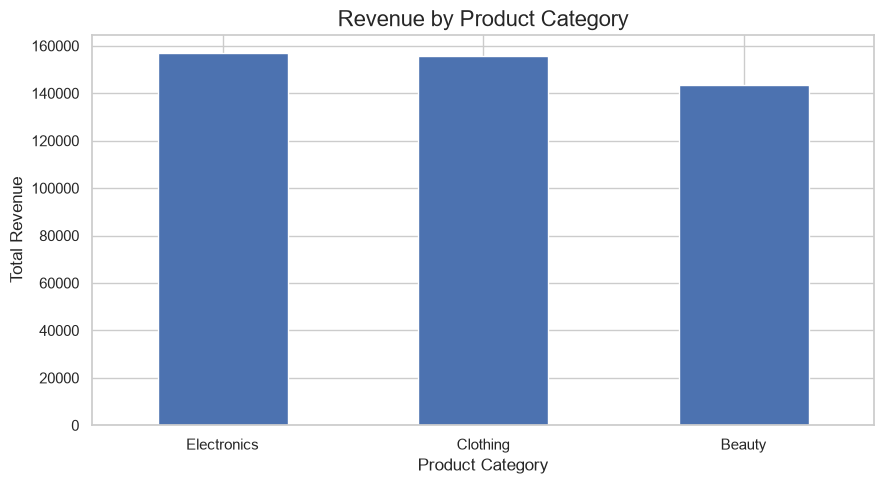

In [22]:
plt.figure(figsize=(9, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

Electronics generates the highest revenue, closely followed by Clothing, while Beauty contributes the lowest revenue among the three categories. An important insight is that Clothing sells the highest number of units but does not generate the highest revenue. This suggests that Electronics has a higher average transaction value and may benefit from higher-priced products.

## 8. Correlation Analysis

Correlation analysis is used to examine the relationships between numerical variables in the dataset. A correlation coefficient close to +1 indicates a strong positive relationship, while a value close to -1 indicates a strong negative relationship. Values near 0 indicate a weak or negligible linear relationship.

In [23]:
correlation_columns = [
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,Age,Quantity,Price per Unit,Total Amount
Age,1.00,-0.02,-0.04,-0.06
Quantity,-0.02,1.00,0.02,0.37
Price per Unit,-0.04,0.02,1.00,0.85
Total Amount,-0.06,0.37,0.85,1.00


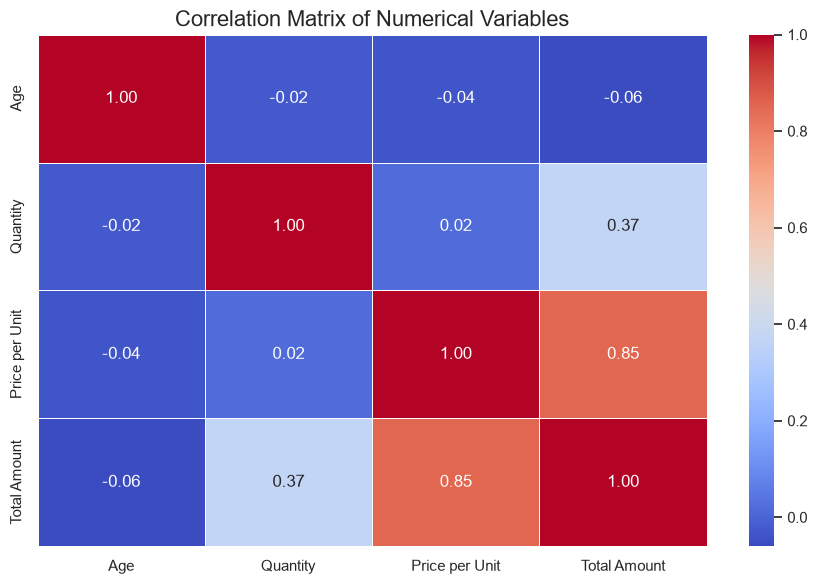

In [24]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

### Observation

The heatmap shows a strong positive correlation of 0.85 between Price per Unit and Total Amount, indicating that higher-priced items are generally associated with higher transaction values. Quantity has a moderate positive correlation of 0.37 with Total Amount, suggesting that purchasing more items also contributes to higher transaction amounts.

Age has very weak correlations with Quantity (-0.02), Price per Unit (-0.04), and Total Amount (-0.06). This indicates that customer age has little linear relationship with purchasing quantity, product price, or transaction value in this dataset.

The correlation analysis suggests that transaction value is influenced more by product pricing and quantity than by customer age.

## 9. Additional Business Insight

### Average Transaction Value by Age Group

Although the correlation analysis indicates that age has a very weak linear relationship with transaction value, customer segments may still differ in their average spending. Therefore, average transaction value is compared across age groups to identify potentially valuable customer segments.

In [25]:
age_group_spending = (
    df.groupby("Age Group", observed=True)["Total Amount"]
    .mean()
    .sort_values(ascending=False)
)

age_group_spending

Age Group
Under 18   534.05
18-25      495.51
26-35      480.39
36-45      454.80
46-55      439.69
56-65      412.36
Name: Total Amount, dtype: float64

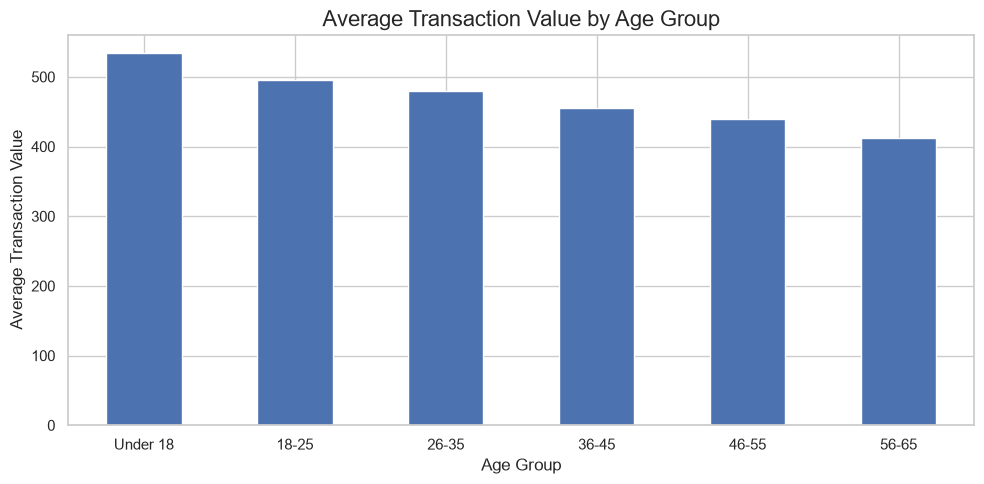

In [26]:
plt.figure(figsize=(10, 5))

age_group_spending.plot(kind="bar")

plt.title("Average Transaction Value by Age Group", fontsize=16)
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Value")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The analysis shows a gradual decline in average transaction value as customer age increases. Customers under 18 have the highest average transaction value at approximately 533, followed by customers aged 18-25 at approximately 494. Customers aged 56-65 have the lowest average transaction value at approximately 410.

This is an interesting finding because the correlation analysis showed almost no linear relationship between age and total transaction value. Segment-level analysis reveals that younger customer groups tend to have higher average transaction values, even though age alone does not strongly explain individual transaction amounts.

## 10. Key Business Metrics

Before drawing the final conclusions, key performance indicators are calculated to summarize overall revenue, transaction value, category performance, and time-based sales performance.

In [27]:
# 1. Total Revenue
total_revenue = df["Total Amount"].sum()

# 2. Average Transaction Value
average_transaction_value = df["Total Amount"].mean()

# 3. Highest Revenue-Generating Category
best_revenue_category = category_revenue.idxmax()
best_revenue_value = category_revenue.max()

# 4. Highest Quantity-Selling Category
best_quantity_category = category_quantity.idxmax()
best_quantity_value = category_quantity.max()

# 5. Age Group with Highest Average Transaction Value
best_age_group = age_group_spending.idxmax()
best_age_group_value = age_group_spending.max()

# 6. Month with Highest Sales
monthly_sales_values = (
    df.groupby("Month")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

best_month = monthly_sales_values.index[0]
best_month_value = monthly_sales_values.iloc[0]

# 7. Quarter with Highest Sales
quarterly_sales_values = (
    df.groupby("Quarter")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

best_quarter = quarterly_sales_values.index[0]
best_quarter_value = quarterly_sales_values.iloc[0]

# Display results
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Transaction Value: {average_transaction_value:,.2f}")
print()
print(f"Highest Revenue Category: {best_revenue_category} ({best_revenue_value:,.2f})")
print(f"Highest Quantity Category: {best_quantity_category} ({best_quantity_value:,.0f} units)")
print()
print(f"Highest Average Transaction Age Group: {best_age_group} ({best_age_group_value:,.2f})")
print()
print(f"Highest Sales Month: {best_month} ({best_month_value:,.2f})")
print(f"Highest Sales Quarter: {best_quarter} ({best_quarter_value:,.2f})")

Total Revenue: 456,000.00
Average Transaction Value: 456.00

Highest Revenue Category: Electronics (156,905.00)
Highest Quantity Category: Clothing (894 units)

Highest Average Transaction Age Group: Under 18 (534.05)

Highest Sales Month: 2023-05 (53,150.00)
Highest Sales Quarter: 2023Q4 (126,190.00)


# 11. Conclusion and Business Recommendations

## Conclusion

The exploratory data analysis of 1,000 retail transactions provides several useful insights into sales performance, customer behaviour, and product category performance. The dataset generated a total revenue of **456,000**, with an average transaction value of **456**.

Electronics generated the highest revenue among the three product categories, contributing **156,905**, while Clothing recorded the highest sales volume with **894 units sold**. This difference indicates that higher sales volume does not necessarily result in the highest revenue, highlighting the importance of considering both quantity and transaction value when evaluating category performance.

The time-series analysis shows fluctuations in sales throughout the year. **May 2023** was the highest-performing month, generating **53,150** in sales, while **Q4 2023** was the strongest quarter with **126,190** in revenue. The low Q1 2024 value should be interpreted cautiously because the dataset contains only a partial period for that quarter.

Customer demographics show a relatively balanced gender distribution. The correlation analysis indicates a strong positive relationship between **Price per Unit and Total Amount (0.85)**, while Quantity has a moderate positive relationship with Total Amount (**0.37**). Age has very weak correlations with transaction-related variables, suggesting that age alone does not strongly explain individual transaction values.

The age-group analysis provides an additional insight: the **Under 18** group recorded the highest average transaction value at approximately **534.05**, followed by the 18–25 group at approximately **494**. However, customer segment size should also be considered before making major targeting decisions.

## Business Recommendations

### 1. Strengthen Electronics Revenue Strategy

Electronics generated the highest category revenue at **156,905**. The business should maintain adequate inventory of high-performing electronics products and consider targeted promotions, bundles, and cross-selling opportunities to further increase revenue from this category.

### 2. Improve Clothing Revenue per Transaction

Clothing recorded the highest quantity sold with **894 units**, but Electronics generated more revenue. The business should investigate opportunities to increase the average transaction value of Clothing through product bundles, complementary-item recommendations, and premium product options.

### 3. Use Pricing Strategically

The correlation analysis showed a strong positive relationship of **0.85 between Price per Unit and Total Amount**. The business should analyze pricing carefully and identify products where customers are willing to purchase higher-priced items. Premium offerings and value-based product bundles could help increase transaction value.

### 4. Plan Marketing Around High-Performing Periods

**May 2023** was the strongest month, while **Q4 2023** was the strongest quarter. The business should examine what products, promotions, or customer behaviours contributed to these periods and consider strengthening inventory and marketing campaigns around similar high-demand periods.

### 5. Segment Customers for Targeted Marketing

The age-group analysis indicates differences in average transaction value, with the Under 18 group showing the highest average transaction value. Rather than applying the same marketing strategy to all customers, the business should evaluate customer segments based on both transaction value and segment size and develop targeted offers accordingly.

## Overall Business Insight

The analysis demonstrates that **sales volume, revenue, pricing, and customer demographics provide different perspectives on business performance**. A combination of category-level analysis, customer segmentation, pricing analysis, and seasonal planning can help the business make more informed decisions and improve revenue performance.
